## UMAP

In [46]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

# wczytanie datasetu
data = pd.read_csv('dataset_eeg_features.csv', header = 0)
data.head()

,FC5,FC3,FC1,FCz,FC2,FC4,FC6,C5,C3,C1,...,PO7,PO3,POz,PO4,PO8,O1,Oz,O2,Iz,Label
0,-11.221173,-11.428977,-11.430309,-11.416710,-11.511942,-11.492775,-11.278689,-11.414317,-11.557047,-11.630472,...,-11.245751,-11.291661,-11.344676,-11.220656,-11.037513,-11.137436,-11.113950,-10.894510,-10.960077,Task3
1,-11.290938,-11.271340,-11.196547,-11.136059,-11.231924,-11.422470,-11.309079,-11.381291,-11.525505,-11.653097,...,-11.013976,-11.031439,-11.015235,-11.122661,-10.954307,-10.965706,-11.033985,-10.878164,-10.914397,Task1
2,-11.256753,-11.425513,-11.474409,-11.344139,-11.321864,-11.373175,-11.331239,-11.368660,-11.531841,-11.657877,...,-10.916364,-10.947545,-11.008806,-10.974645,-10.765495,-10.507537,-10.612376,-10.568103,-10.672120,Task2
3,-11.428553,-11.456729,-11.516519,-11.416696,-11.517260,-11.491750,-11.299328,-11.432945,-11.671538,-11.750713,...,-11.240192,-11.301691,-11.199980,-11.010390,-10.815714,-11.002557,-10.900195,-10.685490,-10.783128,Task1
4,-11.114517,-11.255800,-11.273997,-11.297961,-11.352282,-11.445905,-11.299282,-11.360431,-11.569355,-11.668230,...,-10.938412,-11.023762,-11.050962,-10.924074,-10.742321,-10.750076,-10.825965,-10.646691,-10.772558,Task2


## Współrzędne równoległe dla top 30 najbardziej zmiennych cech EEG

Każda linia na wykresie to jedna próbka EEG, a kolory reprezentują różne klasy zadań. Współrzędne równoległe pozwalają nam zobaczyć, jak różne klasy rozkładają się w przestrzeni cech i które cechy najbardziej je różnicują.

Klasy nie są łatwo separowalne liniowo w oryginalnej przestrzeni, problem jest silnie nieliniowy.

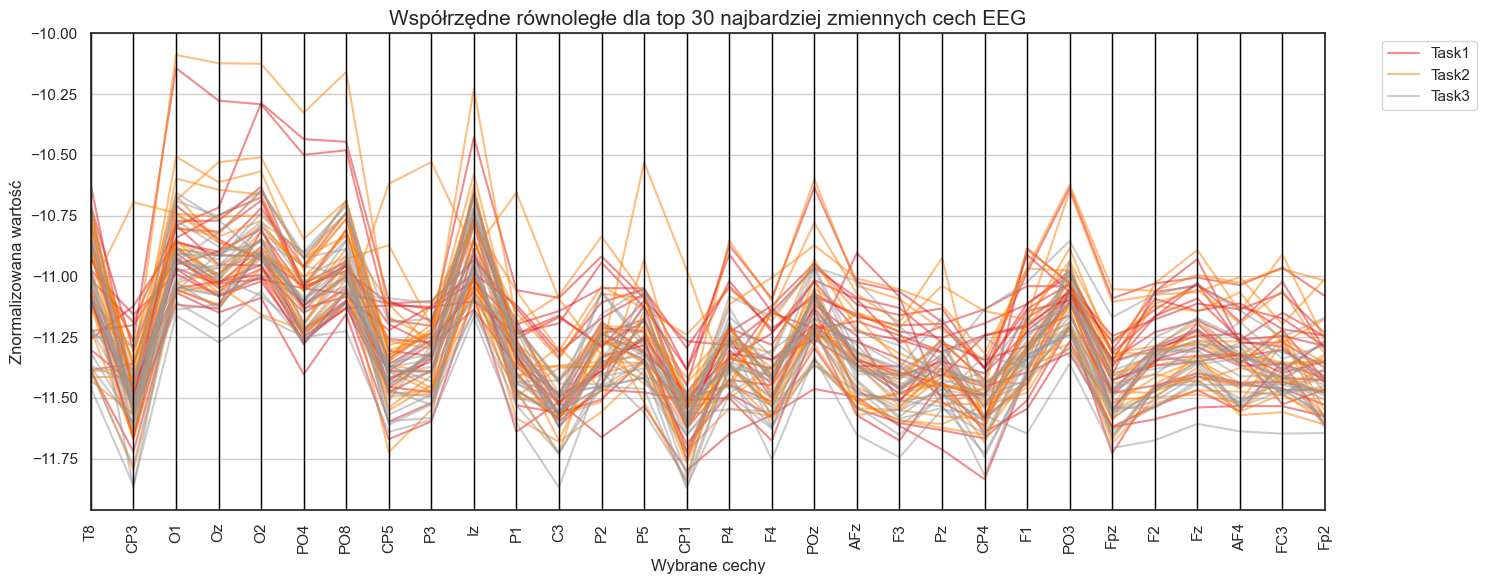

In [47]:
from pandas.plotting import parallel_coordinates

X = data.drop(columns=['Label'])
y = data['Label']

top_features = X.var().nlargest(30).index # top 30 cech o największej wariancji

df_subset = data.groupby('Label').sample(n=20, random_state=42) # wybór 20 próbek z każdej klasy
df_parallel = df_subset[list(top_features) + ['Label']]

plt.figure(figsize=(15, 6))
parallel_coordinates(df_parallel, 'Label', colormap=plt.get_cmap("Set1"), alpha=0.5)
plt.title('Współrzędne równoległe dla top 30 najbardziej zmiennych cech EEG', fontsize=15)
plt.xlabel('Wybrane cechy')
plt.ylabel('Znormalizowana wartość')
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [48]:
def plot_umap(data, embedding, title):
    label_map = {
        "Task1":0, "Task2":1, "Task3":2
    }
    labels_num = data['Label'].map(label_map).fillna(-1).astype(int)

    plt.figure()
    sns.scatterplot(
        x=embedding[:, 0],
        y=embedding[:, 1],
        hue=data['Label'],
        palette="Set1",
        s=15,
        alpha=0.8,
        hue_order=["Task1", "Task2", "Task3"]
    )

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(title, fontsize=18)
    plt.legend(title="Zadanie", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

(87, 2)


/opt/anaconda3/envs/uczenie_maszynowe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


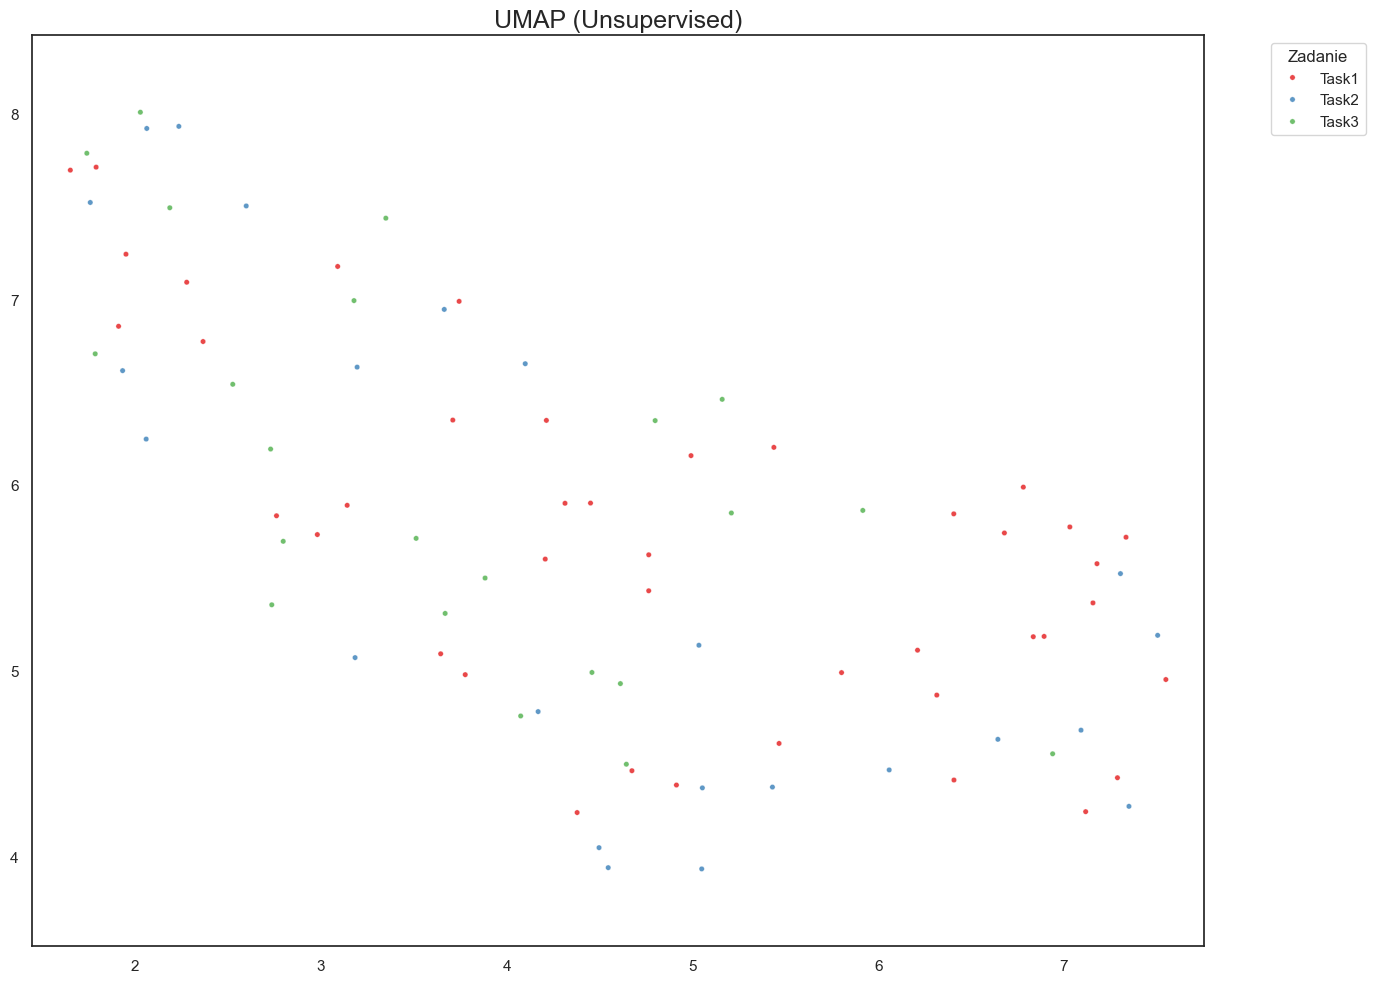

In [51]:
# UMAP NIENADZOROWANY (Unsupervised)
reducer = umap.UMAP(n_components=2, random_state=42)

embedding = reducer.fit_transform(X)
print(embedding.shape)

plot_umap(data, embedding, title="UMAP (Unsupervised)")

The result is an array with 6543 samples, but only two feature columns. This is because, by default, UMAP reduces down to 2D. Each row of the array is a 2-dimensional representation of the corresponding patient.

/opt/anaconda3/envs/uczenie_maszynowe/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


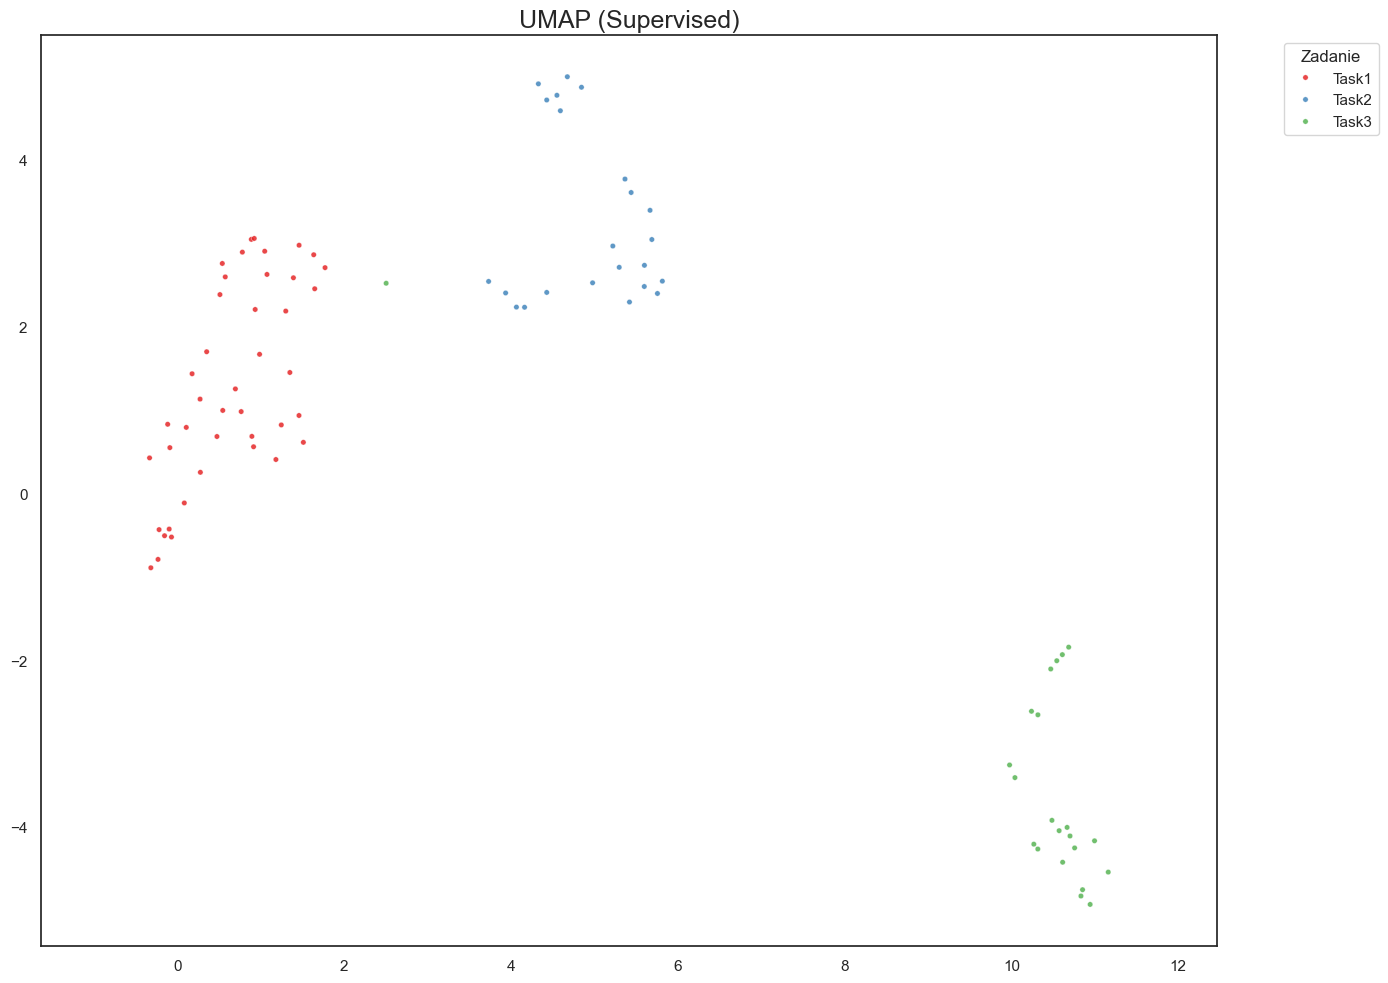

In [50]:
# UMAP NADZOROWANY (Supervised)
label_map = {"Task1":0, "Task2":1, "Task3":2}
y_num = y.map(label_map).fillna(-1).astype(int)

reducer_supervised = umap.UMAP(n_components=2, random_state=42)

embedding_sup = reducer_supervised.fit_transform(X, y=y_num)
embedding.shape

plot_umap(data, embedding_sup, title="UMAP (Supervised)")

## Test 1: trustworthiness

Miara określająca jaki odsetek sąsiadów z przestrzeni wysokowymiarowej pozostaje sąsiadami po redukcji.

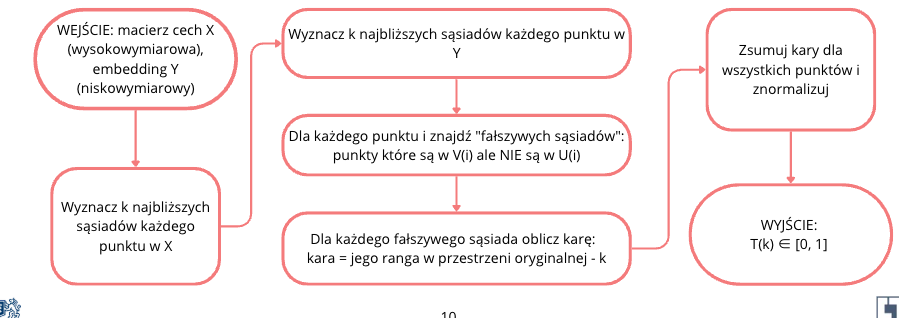

In [57]:
# test 1 UMAP - trustwhorthiness
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness

def calculate_trustworthiness(X, Y, k=5):
    """
    X: macierz cech (wysokowymiarowa, np. Twoje 512 cech)
    Y: embedding (niskowymiarowy, np. 2 wymiary z UMAP)
    k: liczba rozpatrywanych najbliższych sąsiadów

    return: trustworthiness
    """

    n = X.shape[0]
    if k <= 0 or k >= n:
        raise ValueError("k must be > 0 and < n_samples")

    dist_X = pairwise_distances(X) # macierz odległości
    ranks_X = np.argsort(np.argsort(dist_X, axis=1), axis=1)

    dist_Y = pairwise_distances(Y)
    ranks_Y = np.argsort(np.argsort(dist_Y, axis=1), axis=1)

    suma_kar = 0

    for i in range(n):
        U_i = np.where((ranks_X[i] >= 1) & (ranks_X[i] <= k))[0] # U(i) - przestrzeń oryginalna
        V_i = np.where((ranks_Y[i] >= 1) & (ranks_Y[i] <= k))[0] # V(i) - przestrzeń po umap

        falszywi_sasiedzi = [j for j in V_i if j not in U_i]

        for j in falszywi_sasiedzi:
            kara =  ranks_X[i, j] - k
            suma_kar += kara

    normalizacja = 2.0 / (n * k * (2 * n - 3 * k - 1))
    T_k = (1.0 - normalizacja * suma_kar)

    return T_k

trustworthiness_unsupervised = calculate_trustworthiness(X, embedding)
trustworthiness_supervised = calculate_trustworthiness(X, embedding_sup)

print(f"Trustworthiness unsupervised (k=5): {trustworthiness_unsupervised:.4f}")
print(f"Trustworthiness supervised (k=5): {trustworthiness_supervised:.4f}")

# sprawdzenie wartości dla gotowej funkcji z biblioteki sklearn
trustworthiness_unsupervised_sklearn = trustworthiness(X, embedding, n_neighbors=5)
trustworthiness_supervised_sklearn = trustworthiness(X, embedding_sup, n_neighbors=5)

print(f"Trustworthiness unsupervised (k=5): {trustworthiness_unsupervised_sklearn:.4f}")
print(f"Trustworthiness supervised (k=5): {trustworthiness_supervised_sklearn:.4f}")

Trustworthiness unsupervised (k=5): 0.9022
Trustworthiness supervised (k=5): 0.8600
Trustworthiness unsupervised (k=5): 0.9022
Trustworthiness supervised (k=5): 0.8600


## Test 2: zachowanie sąsiedztwa

Jaki procent k najbliższych sąsiadów danego punktu jest wspólny przed i po redukcji wymiarów?

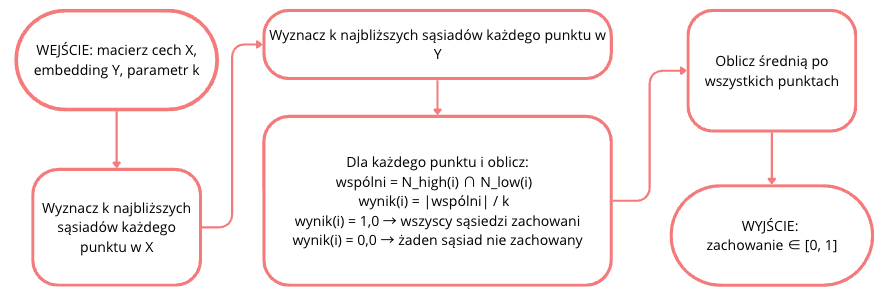

In [58]:
# test 2 UMAP - zachowanie sąsiedztwa
import numpy as np
from sklearn.neighbors import NearestNeighbors

def calculate_neighborhood_preservation(X, Y, k=5):
    """
    X: macierz cech przed redukcją (np. oryginalne EEG)
    Y: embedding po redukcji (np. wynik z UMAP)
    k: liczba rozpatrywanych najbliższych sąsiadów
    """
    n = X.shape[0]

    nn_X = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X)
    _, indices_X = nn_X.kneighbors(X)

    nn_Y = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(Y)
    _, indices_Y = nn_Y.kneighbors(Y)

    suma_wynikow = 0.0

    for i in range(n):
        N_high = set(indices_X[i, 1:])
        N_low  = set(indices_Y[i, 1:])

        wspolni = N_high.intersection(N_low)

        wynik_i = len(wspolni) / k
        suma_wynikow += wynik_i

    srednie_zachowanie = suma_wynikow / n

    return srednie_zachowanie

neighborhood_preservation_unsupervised = calculate_neighborhood_preservation(X, embedding)
neighborhood_preservation_supervised = calculate_neighborhood_preservation(X, embedding_sup)

print(f"Neighborhood Preservation unsupervised (k=5): {neighborhood_preservation_unsupervised:.4f}")
print(f"Neighborhood Preservation supervised (k=5): {neighborhood_preservation_supervised:.4f}")

Neighborhood Preservation unsupervised (k=5): 0.4920
Neighborhood Preservation supervised (k=5): 0.3195
